In [6]:
# --- Setup & Imports ---
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


In [18]:
# Install kagglehub if needed (Kaggle usually already has it)
!pip install kagglehub[pandas-datasets] --quiet

import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

# --------------------------------------------------------
# 1. Download dataset directory
# --------------------------------------------------------
# Use dataset_download to get the local path to the dataset directory.
CEDAR_DIR = kagglehub.dataset_download("shreelakshmigp/cedardataset")

print("Dataset downloaded to:", CEDAR_DIR)

# --------------------------------------------------------
# 2. Inspect available files
# --------------------------------------------------------
# The CEDAR dataset consists of image files organized in subdirectories.
# We will iterate through the main directory to find the image paths.
for root, dirs, files in os.walk(CEDAR_DIR):
    for f in files:
        print(os.path.join(root, f))

# --------------------------------------------------------
# 3. Choose the file you want to load
# --------------------------------------------------------
# The original intent here was to load a single file into a DataFrame,
# but for this image dataset, we need the base directory. CEDAR_DIR is now set correctly.
# No changes are needed here, as CEDAR_DIR is now the root path.

# --------------------------------------------------------
# 4. Load the dataset using kagglehub
# --------------------------------------------------------
# This section was for loading a DataFrame, which is not applicable for this image dataset.
# The CEDAR_DIR variable now correctly holds the path to the dataset directory
# for use in subsequent image processing cells.
# Removing the DataFrame loading attempt.


Using Colab cache for faster access to the 'cedardataset' dataset.
Dataset downloaded to: /kaggle/input/cedardataset
/kaggle/input/cedardataset/signatures/Readme.txt
/kaggle/input/cedardataset/signatures/full_org/original_52_13.png
/kaggle/input/cedardataset/signatures/full_org/original_54_12.png
/kaggle/input/cedardataset/signatures/full_org/original_52_7.png
/kaggle/input/cedardataset/signatures/full_org/original_5_19.png
/kaggle/input/cedardataset/signatures/full_org/original_50_21.png
/kaggle/input/cedardataset/signatures/full_org/original_27_1.png
/kaggle/input/cedardataset/signatures/full_org/original_32_23.png
/kaggle/input/cedardataset/signatures/full_org/original_19_15.png
/kaggle/input/cedardataset/signatures/full_org/original_55_19.png
/kaggle/input/cedardataset/signatures/full_org/original_12_1.png
/kaggle/input/cedardataset/signatures/full_org/original_44_4.png
/kaggle/input/cedardataset/signatures/full_org/original_21_14.png
/kaggle/input/cedardataset/signatures/full_org/

Count Genuine & Forgery per Writer

In [20]:
cedar_counts = defaultdict(lambda: {"genuine": 0, "forgery": 0})

# Use os.walk to traverse all subdirectories and find image files
for root, dirs, files in os.walk(CEDAR_DIR):
    for f in files:
        # Ensure we are processing image files and not other files like 'Readme.txt'
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            fname = f.lower()
            # Extract writer ID and type from the filename
            # Example: 'original_52_13.png' -> type 'original', writer_id '52'
            # Example: 'forgeries_13_22.png' -> type 'forgeries', writer_id '13'
            parts = fname.split('_')
            if len(parts) >= 3: # Expect at least 'type_writerid_filenumber.png'
                signature_type = parts[0]
                writer_id = parts[1]

                if signature_type == "original":
                    cedar_counts[writer_id]["genuine"] += 1
                elif signature_type == "forgeries":
                    cedar_counts[writer_id]["forgery"] += 1

print("Total writers =", len(cedar_counts))
print("Writer 1 counts =", cedar_counts["1"])

Total writers = 55
Writer 1 counts = {'genuine': 24, 'forgery': 24}


Extract Image Size Stats

In [21]:
from PIL import Image
import numpy as np

image_sizes = []

# Use os.walk to traverse all subdirectories and find image files
for root, dirs, files in os.walk(CEDAR_DIR):
    for f in files:
        # Ensure we are processing image files and not other files like 'Readme.txt'
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, f)
            try:
                img = Image.open(img_path).convert("L")
                w, h = img.size
                image_sizes.append([w, h])
            except Exception as e:
                print(f"Error opening image {img_path}: {e}")

sizes = np.array(image_sizes)

print("Width  (min/median/max):", sizes[:, 0].min(), np.median(sizes[:, 0]), sizes[:, 0].max())
print("Height (min/median/max):", sizes[:, 1].min(), np.median(sizes[:, 1]), sizes[:, 1].max())

Width  (min/median/max): 264 576.0 888
Height (min/median/max): 145 342.0 816


Pixel Intensity Summary

In [22]:
pixel_means = []
pixel_stds = []

# Use os.walk to traverse all subdirectories and find image files
for root, dirs, files in os.walk(CEDAR_DIR):
    for f in files:
        # Ensure we are processing image files and not other files like 'Readme.txt'
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, f)
            try:
                img = Image.open(img_path).convert("L")
                arr = np.array(img)
                pixel_means.append(arr.mean())
                pixel_stds.append(arr.std())
            except Exception as e:
                print(f"Error opening image {img_path}: {e}")

print("Dataset mean pixel intensity =", np.mean(pixel_means))
print("Dataset intensity standard deviation =", np.mean(pixel_stds))

Dataset mean pixel intensity = 242.16433673433616
Dataset intensity standard deviation = 20.341881897471335


Show Random Genuine & Forgery Examples

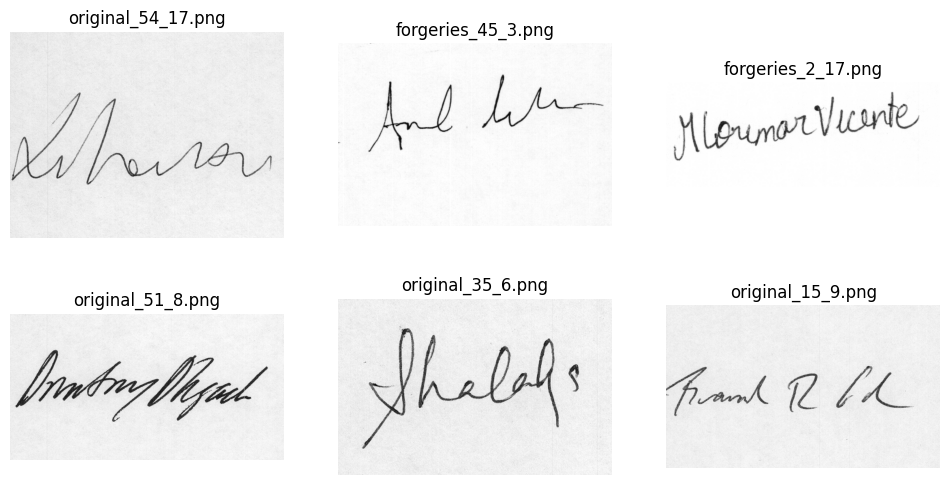

In [23]:
import matplotlib.pyplot as plt
import random
import os

all_image_paths = []
# Use os.walk to gather all image paths first
for root, dirs, files in os.walk(CEDAR_DIR):
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_image_paths.append(os.path.join(root, f))

sample_paths = []
# Randomly select 6 image paths from the collected list
if len(all_image_paths) >= 6:
    sample_paths = random.sample(all_image_paths, 6)
else:
    print("Not enough images found to display 6 samples.")
    sample_paths = all_image_paths # Display all if less than 6

if sample_paths:
    plt.figure(figsize=(12,6))
    for i, path in enumerate(sample_paths):
        plt.subplot(2, 3, i+1)
        plt.imshow(Image.open(path).convert("L"), cmap="gray")
        plt.title(os.path.basename(path))
        plt.axis("off")
    plt.show()
else:
    print("No image files found in the dataset.")

Image Width & Height Histograms

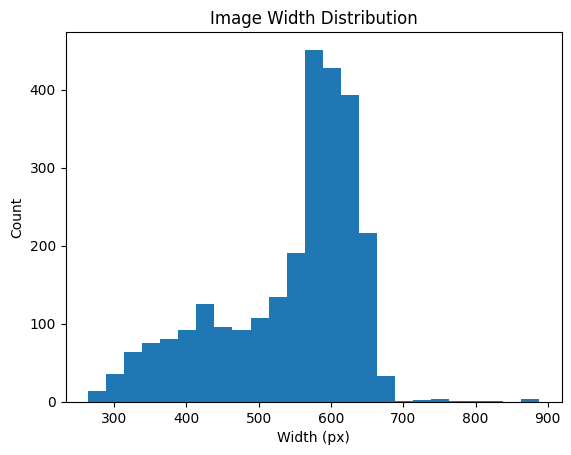

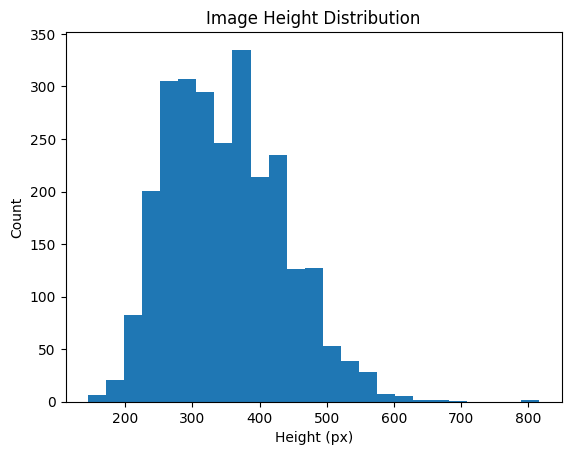

In [24]:
plt.hist(sizes[:, 0], bins=25)
plt.title("Image Width Distribution")
plt.xlabel("Width (px)")
plt.ylabel("Count")
plt.show()

plt.hist(sizes[:, 1], bins=25)
plt.title("Image Height Distribution")
plt.xlabel("Height (px)")
plt.ylabel("Count")
plt.show()


Mean Pixel Intensity Distribution

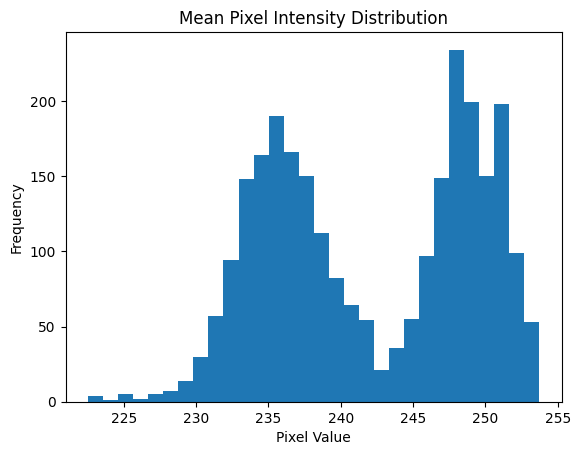

In [25]:
plt.hist(pixel_means, bins=30)
plt.title("Mean Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


Compare Genuine vs Forgery Pixel Statistics

This shows whether forged signatures are generally lighter/darker, more/less textured, etc.

In [26]:
# --- Compare Genuine vs Forgery Pixel Stats ---
genuine_means, genuine_stds = [], []
forgery_means, forgery_stds = [], []

# Use os.walk to traverse all subdirectories and find image files
for root, dirs, files in os.walk(CEDAR_DIR):
    for f in files:
        # Ensure we are processing image files and not other files like 'Readme.txt'
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, f)
            try:
                img = Image.open(img_path).convert("L")
                arr = np.array(img)

                fname = f.lower()
                # Determine if it's a 'forgery' or 'original' based on filename prefix
                if fname.startswith("forgeries"):
                    forgery_means.append(arr.mean())
                    forgery_stds.append(arr.std())
                elif fname.startswith("original"):
                    genuine_means.append(arr.mean())
                    genuine_stds.append(arr.std())
            except Exception as e:
                print(f"Error opening image {img_path}: {e}")

# Check if lists are not empty before calculating means
if genuine_means:
    print("Genuine mean intensity     =", np.mean(genuine_means))
    print("Genuine intensity standard deviation =", np.mean(genuine_stds))
else:
    print("No genuine signatures found to calculate statistics.")

if forgery_means:
    print("Forgery mean intensity     =", np.mean(forgery_means))
    print("Forgery intensity standard deviation =", np.mean(forgery_stds))
else:
    print("No forgery signatures found to calculate statistics.")


Genuine mean intensity     = 235.72184355955088
Genuine intensity standard deviation = 19.759188554839714
Forgery mean intensity     = 248.60682990912142
Forgery intensity standard deviation = 20.92457524010295


Signature Bounding Box Tightness (White-Margin Ratio)

This tells you how much empty space (white area) exists in the signature image — useful for preprocessing & cropping.

In [27]:
# --- Bounding box analysis: white-margin ratio ---
white_ratios = []

# Use os.walk to traverse all subdirectories and find image files
for root, dirs, files in os.walk(CEDAR_DIR):
    for f in files:
        # Ensure we are processing image files and not other files like 'Readme.txt'
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, f)
            try:
                img = np.array(Image.open(img_path).convert("L"))

                # threshold to identify ink (signature strokes)
                mask = img < 200  # dark = strokes

                if mask.sum() == 0:
                    continue  # empty image edge case

                # bounding box
                rows = np.any(mask, axis=1)
                cols = np.any(mask, axis=0)
                ymin, ymax = np.where(rows)[0][0], np.where(rows)[0][-1]
                xmin, xmax = np.where(cols)[0][0], np.where(cols)[0][-1]

                bbox_area = (ymax - ymin + 1) * (xmax - xmin + 1)
                img_area = img.shape[0] * img.shape[1]

                white_ratios.append(bbox_area / img_area)
            except Exception as e:
                print(f"Error opening image {img_path}: {e}")

# Check if white_ratios is not empty before calculating statistics
if white_ratios:
    print("Average bounding-box / image-area ratio:", np.mean(white_ratios))
    print("Min ratio:", np.min(white_ratios))
    print("Max ratio:", np.max(white_ratios))
else:
    print("No valid images found to calculate bounding box ratios.")

Average bounding-box / image-area ratio: 0.5935304554994145
Min ratio: 0.15604938271604937
Max ratio: 1.0
